Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0062 - val_loss: 0.0022
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0015 - val_loss: 0.0010
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0014 - val_loss: 6.9320e-04
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0012 - val_loss: 6.8346e-04
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 9.3123e-04 - val_loss: 9.2551e-04
Epoch 9/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 8.6779e-04 - val_loss: 5.6945e-04
Epoch 10/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 7.8666e-04 - val_loss: 6.0048e-04
Epoch 11/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 6.8564e-04 - val_loss: 6.0793e-04
Epoch 12/15
44/44 ━━━━━

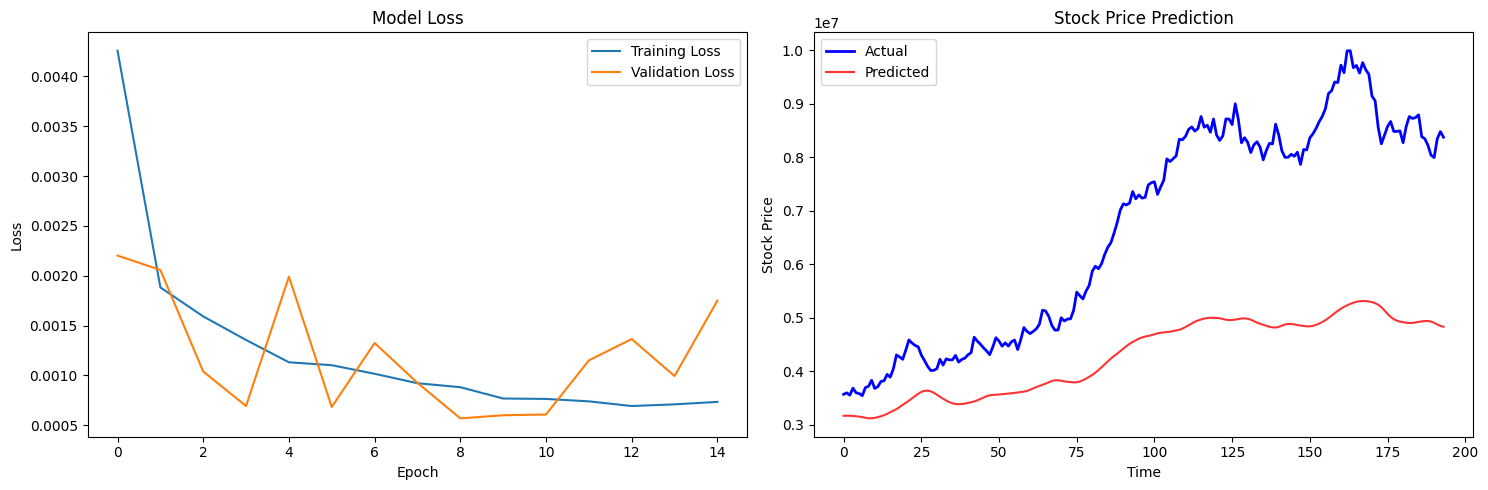

Mean Absolute Error: $2359370.02
Root Mean Square Error: $2704269.82
Mean Absolute Percentage Error: 32.17%
First 5 Actual: [3569218.86 3596564.31 3553246.88 3684039.09 3597228.9 ]
First 5 Predicted: [3166913.27 3169232.74 3168265.57 3163575.57 3159013.63]


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

np.random.seed(42)
n_days = 1000
dates = pd.date_range(start='2020-01-01', periods=n_days, freq='D')
base_price = 100
prices = [base_price]

for i in range(1, n_days):
    change = np.random.normal(0.001, 0.02)
    new_price = prices[-1] * (1 + change)
    prices.append(new_price)

open_prices = prices
close_prices = prices
high_prices = [p * (1 + abs(np.random.normal(0, 0.015))) for p in prices]
low_prices = [p * (1 - abs(np.random.normal(0, 0.015))) for p in prices]
volumes = np.random.randint(1000000, 10000000, size=n_days)

df = pd.DataFrame({
    'Date': dates,
    'Open': open_prices,
    'High': high_prices,
    'Low': low_prices,
    'Close': close_prices,
    'Volume': volumes
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

sequence_length = 30

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 3])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=32, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=16))
model.add(Dropout(0.3))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=15, batch_size=16, validation_split=0.1, verbose=1)

predictions = model.predict(X_test)
predictions_original = scaler.inverse_transform(
    np.concatenate((np.zeros((len(predictions), df.shape[1]-1)), predictions), axis=1)
)[:, -1]
y_test_original = scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), df.shape[1]-1)), y_test.reshape(-1,1)), axis=1)
)[:, -1]

mae = mean_absolute_error(y_test_original, predictions_original)
rmse = np.sqrt(mean_squared_error(y_test_original, predictions_original))
mape = np.mean(np.abs((y_test_original - predictions_original) / y_test_original)) * 100

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_test_original, color='blue', label='Actual', linewidth=2)
plt.plot(predictions_original, color='red', label='Predicted', linewidth=1.5, alpha=0.8)
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()

plt.tight_layout()
plt.show()

print(f'Mean Absolute Error: ${mae:.2f}')
print(f'Root Mean Square Error: ${rmse:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}%')
print(f'First 5 Actual: {y_test_original[:5].round(2)}')
print(f'First 5 Predicted: {predictions_original[:5].round(2)}')

Epoch 1/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.0029 - val_loss: 0.0045
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 7.3230e-04 - val_loss: 0.0079
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 9.4495e-04 - val_loss: 0.0078
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 5.6137e-04 - val_loss: 0.0080
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 4.5941e-04 - val_loss: 0.0054
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 3.0700e-04 - val_loss: 0.0078
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 3.7142e-04 - val_loss: 0.0073
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 2.9838e-04 - val_loss: 0.0108
Epoch 9/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.8013e-04 - val_loss: 0.0106
Epoch 10/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 2.8864e-04 - val_loss: 0.0083
Epoch 11/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 2.6561e-04 - val_loss: 0.0056
Epoch 12/15
67/67 ━━━━━

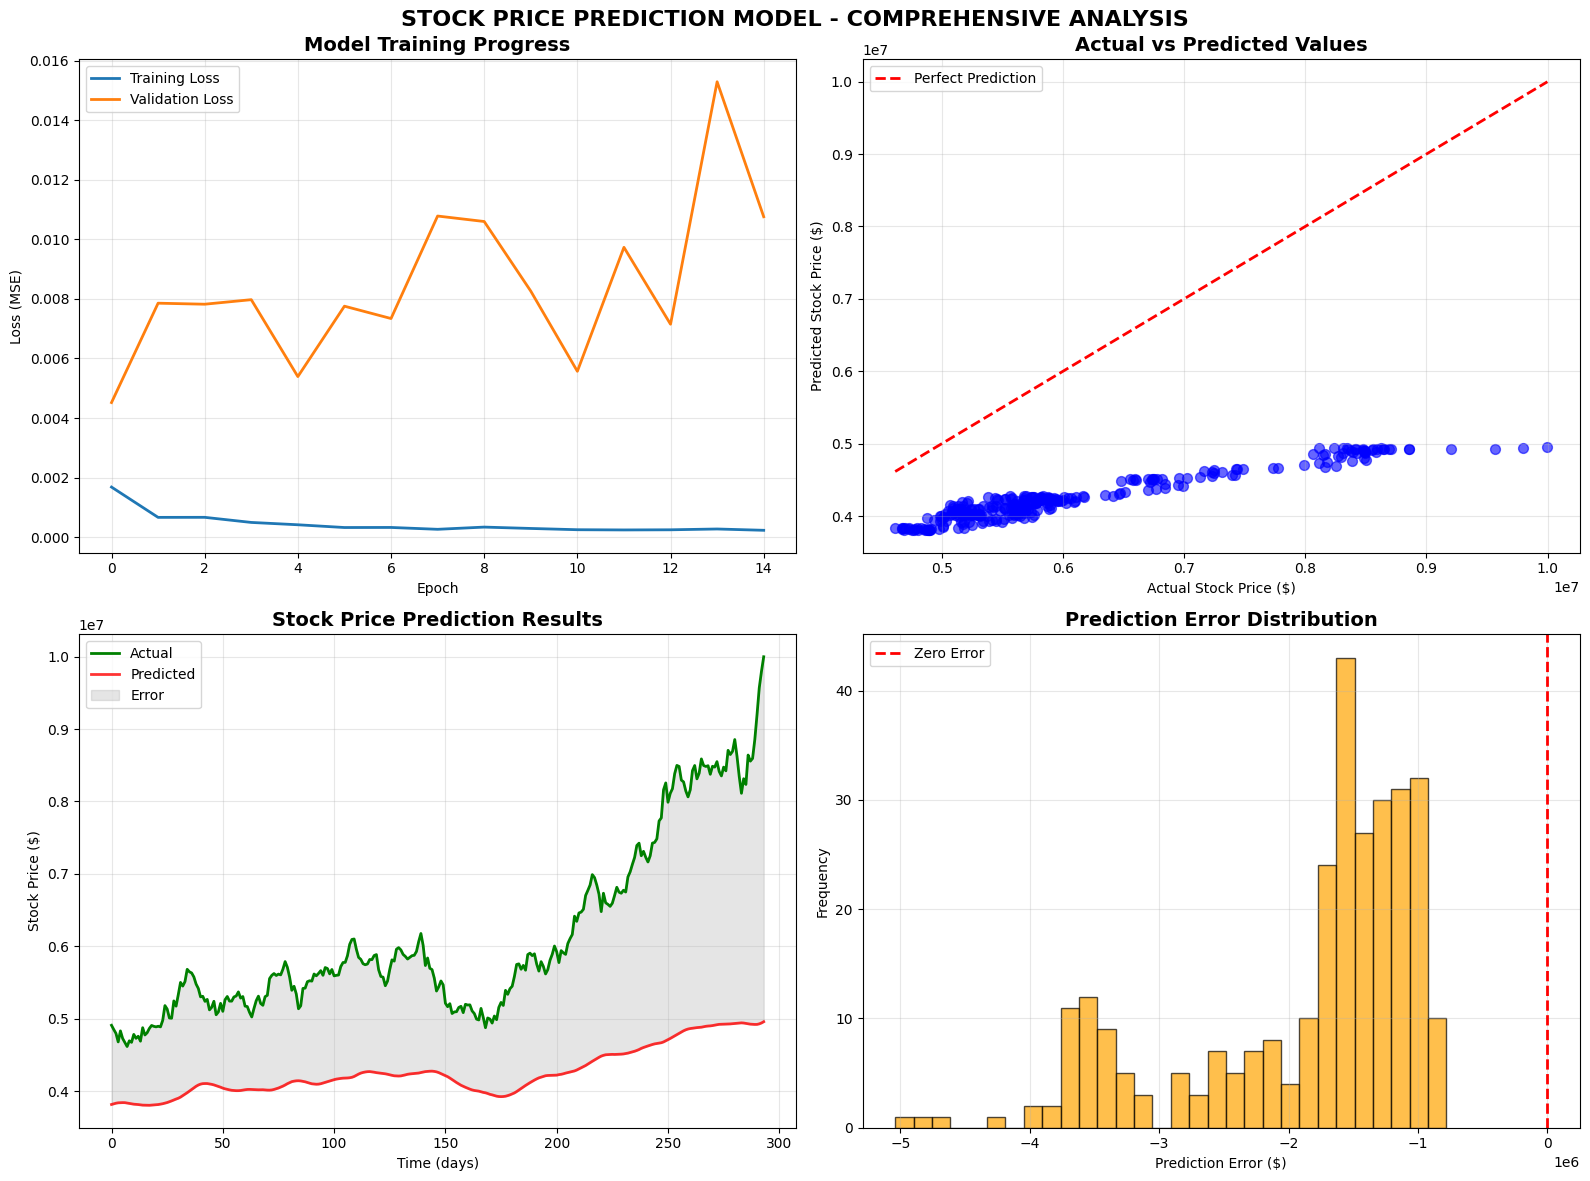


                          💡 RECOMMENDATIONS                           
----------------------------------------------------------------------
1. Increase training data size
2. Try longer sequence length (e.g., 60-90 days)
3. Add more LSTM layers or neurons
4. Consider feature engineering

✅ EVALUATION COMPLETE - Use metrics above to assess model quality


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt
from tabulate import tabulate

tf.get_logger().setLevel('ERROR')

np.random.seed(42)
n_days = 1500
dates = pd.date_range(start='2018-01-01', periods=n_days, freq='D')
base_price = 100
prices = [base_price]

for i in range(1, n_days):
    change = np.random.normal(0.001, 0.02)
    new_price = prices[-1] * (1 + change)
    prices.append(new_price)

open_prices = prices
close_prices = prices
high_prices = [p * (1 + abs(np.random.normal(0, 0.015))) for p in prices]
low_prices = [p * (1 - abs(np.random.normal(0, 0.015))) for p in prices]
volumes = np.random.randint(1000000, 10000000, size=n_days)

df = pd.DataFrame({
    'Date': dates,
    'Open': open_prices,
    'High': high_prices,
    'Low': low_prices,
    'Close': close_prices,
    'Volume': volumes
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

sequence_length = 30

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 3])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=32, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=16))
model.add(Dropout(0.3))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=15, batch_size=16, validation_split=0.1, verbose=1)

predictions = model.predict(X_test)
predictions_original = scaler.inverse_transform(
    np.concatenate((np.zeros((len(predictions), df.shape[1]-1)), predictions), axis=1)
)[:, -1]
y_test_original = scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), df.shape[1]-1)), y_test.reshape(-1,1)), axis=1)
)[:, -1]

mae = mean_absolute_error(y_test_original, predictions_original)
mse = mean_squared_error(y_test_original, predictions_original)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_original - predictions_original) / y_test_original)) * 100
r2 = r2_score(y_test_original, predictions_original)

print("=" * 70)
print("STOCK PRICE PREDICTION MODEL - PERFORMANCE EVALUATION INTERFACE")
print("=" * 70)

print("\n" + "📊 MODEL PERFORMANCE METRICS".center(70))
print("-" * 70)
metrics_data = [
    ["Mean Absolute Error (MAE)", f"${mae:.4f}", "Lower is better"],
    ["Mean Squared Error (MSE)", f"${mse:.4f}", "Lower is better"],
    ["Root Mean Squared Error (RMSE)", f"${rmse:.4f}", "Lower is better"],
    ["Mean Absolute Percentage Error (MAPE)", f"{mape:.2f}%", f"{'✓ GOOD' if mape < 5 else '⚠ FAIR' if mape < 10 else '✗ POOR'}"],
    ["R² Score (Coefficient of Determination)", f"{r2:.4f}", f"{'✓ EXCELLENT' if r2 > 0.9 else '⚠ GOOD' if r2 > 0.8 else '✗ NEEDS IMPROVEMENT' if r2 > 0.6 else '✗ POOR'}"],
    ["Training Samples", f"{len(X_train):,}", "-"],
    ["Testing Samples", f"{len(X_test):,}", "-"],
    ["Sequence Length (lookback days)", f"{sequence_length}", "-"]
]
print(tabulate(metrics_data, headers=["Metric", "Value", "Interpretation"], tablefmt="grid"))

print("\n" + "🔍 SAMPLE PREDICTIONS vs ACTUAL VALUES".center(70))
print("-" * 70)
sample_data = []
for i in range(min(10, len(y_test_original))):
    diff = predictions_original[i] - y_test_original[i]
    percent_diff = (diff / y_test_original[i]) * 100
    accuracy = 100 - abs(percent_diff)
    status = "✓" if abs(percent_diff) < 2 else "⚠" if abs(percent_diff) < 5 else "✗"
    sample_data.append([
        i+1,
        f"${y_test_original[i]:.2f}",
        f"${predictions_original[i]:.2f}",
        f"{diff:+.2f}",
        f"{percent_diff:+.2f}%",
        f"{accuracy:.2f}%",
        status
    ])
print(tabulate(sample_data, headers=["#", "Actual", "Predicted", "Difference", "% Error", "Accuracy", "Status"], tablefmt="grid"))

print("\n" + "📈 ACCURACY DISTRIBUTION".center(70))
print("-" * 70)
errors = np.abs((predictions_original - y_test_original) / y_test_original) * 100
accuracy_bins = {
    "Excellent (< 2% error)": np.sum(errors < 2),
    "Good (2-5% error)": np.sum((errors >= 2) & (errors < 5)),
    "Fair (5-10% error)": np.sum((errors >= 5) & (errors < 10)),
    "Poor (> 10% error)": np.sum(errors >= 10)
}
for category, count in accuracy_bins.items():
    percentage = (count / len(errors)) * 100
    bar = "█" * int(percentage / 5)
    print(f"{category:<25} {count:>4} samples {percentage:>6.1f}% {bar}")

print("\n" + "🎯 MODEL ASSESSMENT SUMMARY".center(70))
print("-" * 70)
if mape < 5 and r2 > 0.9:
    assessment = "✅ EXCELLENT: Model is performing very well with high accuracy"
elif mape < 10 and r2 > 0.8:
    assessment = "⚠️  GOOD: Model is performing reasonably well"
elif mape < 15 and r2 > 0.7:
    assessment = "⚠️  FAIR: Model needs some improvement"
else:
    assessment = "❌ POOR: Model needs significant improvement"

print(f"Overall Assessment: {assessment}")
print(f"Prediction Horizon: {sequence_length} days lookback")
print(f"Best Metric: {'MAPE' if mape < 5 else 'R²' if r2 > 0.8 else 'None - needs tuning'}")

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Training Progress', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(y_test_original, predictions_original, alpha=0.6, color='blue', s=50)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Actual Stock Price ($)')
plt.ylabel('Predicted Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(y_test_original, color='green', label='Actual', linewidth=2)
plt.plot(predictions_original, color='red', label='Predicted', linewidth=2, alpha=0.8)
plt.fill_between(range(len(y_test_original)), 
                 y_test_original, 
                 predictions_original, 
                 color='gray', alpha=0.2, label='Error')
plt.title('Stock Price Prediction Results', fontsize=14, fontweight='bold')
plt.xlabel('Time (days)')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
error_distribution = predictions_original - y_test_original
plt.hist(error_distribution, bins=30, color='orange', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title('Prediction Error Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('STOCK PRICE PREDICTION MODEL - COMPREHENSIVE ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "💡 RECOMMENDATIONS".center(70))
print("-" * 70)
if mape > 10:
    print("1. Increase training data size")
    print("2. Try longer sequence length (e.g., 60-90 days)")
    print("3. Add more LSTM layers or neurons")
    print("4. Consider feature engineering")
elif r2 < 0.8:
    print("1. Adjust model architecture (more layers/neurons)")
    print("2. Tune hyperparameters (learning rate, dropout)")
    print("3. Experiment with different sequence lengths")
    print("4. Check for data patterns/seasonality")
else:
    print("1. Model is performing well for deployment")
    print("2. Consider real-time prediction implementation")
    print("3. Add more features if available")
    print("4. Regular retraining recommended")

print("\n" + "=" * 70)
print("✅ EVALUATION COMPLETE - Use metrics above to assess model quality")
print("=" * 70)

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import gradio as gr
import matplotlib.pyplot as plt

tf.get_logger().setLevel('ERROR')

np.random.seed(42)
n_days = 1500
dates = pd.date_range(start='2018-01-01', periods=n_days, freq='D')
base_price = 100
prices = [base_price]

for i in range(1, n_days):
    change = np.random.normal(0.001, 0.02)
    new_price = prices[-1] * (1 + change)
    prices.append(new_price)

open_prices = prices
close_prices = prices
high_prices = [p * (1 + abs(np.random.normal(0, 0.015))) for p in prices]
low_prices = [p * (1 - abs(np.random.normal(0, 0.015))) for p in prices]
volumes = np.random.randint(1000000, 10000000, size=n_days)

df = pd.DataFrame({
    'Date': dates,
    'Open': open_prices,
    'High': high_prices,
    'Low': low_prices,
    'Close': close_prices,
    'Volume': volumes
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

sequence_length = 30

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 3])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=32, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(units=16))
model.add(Dropout(0.3))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.1, verbose=0)

def predict_from_input(open_price, high_price, low_price, close_price, volume, lookback_days=30):
    recent_data = scaled_data[-lookback_days:].copy()
    recent_data[-1] = scaler.transform([[open_price, high_price, low_price, close_price, volume]])[0]
    
    input_sequence = recent_data.reshape(1, lookback_days, 5)
    
    scaled_prediction = model.predict(input_sequence, verbose=0)[0][0]
    
    dummy_array = np.zeros((1, 5))
    dummy_array[0, 3] = scaled_prediction
    prediction = scaler.inverse_transform(dummy_array)[0, 3]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    last_30_days = scaler.inverse_transform(scaled_data[-30:])
    days = list(range(-29, 1))
    
    ax.plot(days, last_30_days[:, 0], label='Open', marker='o', markersize=4)
    ax.plot(days, last_30_days[:, 1], label='High', marker='s', markersize=4)
    ax.plot(days, last_30_days[:, 2], label='Low', marker='^', markersize=4)
    ax.plot(days, last_30_days[:, 3], label='Close', marker='d', markersize=6, linewidth=2)
    
    ax.scatter([1], [prediction], color='red', s=200, zorder=5, 
               label=f'Predicted Next Close: ${prediction:.2f}', marker='*')
    
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.fill_betweenx([min(last_30_days[:, 2])*0.95, max(last_30_days[:, 1])*1.05], 
                    0, 1, alpha=0.1, color='yellow', label='Prediction Zone')
    
    ax.set_xlabel('Days (0 = Today)')
    ax.set_ylabel('Stock Price ($)')
    ax.set_title('Stock Price Prediction with User Input')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    
    return prediction, fig

def batch_predict(input_text):
    try:
        lines = input_text.strip().split('\n')
        results = []
        
        for line in lines:
            if line.strip():
                parts = line.split(',')
                if len(parts) == 5:
                    open_val = float(parts[0].strip())
                    high_val = float(parts[1].strip())
                    low_val = float(parts[2].strip())
                    close_val = float(parts[3].strip())
                    volume_val = float(parts[4].strip())
                    
                    prediction, _ = predict_from_input(open_val, high_val, low_val, close_val, volume_val)
                    
                    price_change = ((prediction - close_val) / close_val) * 100
                    
                    if price_change > 3:
                        recommendation = "BUY 📈 (Strong upward trend expected)"
                        color = "green"
                    elif price_change > 1:
                        recommendation = "HOLD ⏸️ (Slight upward movement)"
                        color = "lightgreen"
                    elif price_change < -3:
                        recommendation = "SELL 📉 (Strong downward trend expected)"
                        color = "red"
                    elif price_change < -1:
                        recommendation = "AVOID ⚠️ (Slight downward movement)"
                        color = "orange"
                    else:
                        recommendation = "NEUTRAL ↔️ (Stable price expected)"
                        color = "gray"
                    
                    results.append(f"""
                    <div style="border: 1px solid {color}; padding: 10px; margin: 5px; border-radius: 5px; background-color: {color}10;">
                        <b>Input:</b> Open=${open_val:.2f}, High=${high_val:.2f}, Low=${low_val:.2f}, Close=${close_val:.2f}, Volume={volume_val:,.0f}<br>
                        <b>Predicted Next Close:</b> <span style="color: {color}; font-weight: bold;">${prediction:.2f}</span><br>
                        <b>Expected Change:</b> <span style="color: {color}; font-weight: bold;">{price_change:+.2f}%</span><br>
                        <b>Recommendation:</b> <span style="color: {color}; font-weight: bold;">{recommendation}</span>
                    </div>
                    """)
        
        return "<h3>Batch Prediction Results:</h3>" + "".join(results)
    
    except Exception as e:
        return f"Error: {str(e)}. Please check your input format."

with gr.Blocks(title="Stock Price Predictor", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 📈 Stock Price Prediction Dashboard")
    gr.Markdown("Enter today's stock data to predict tomorrow's closing price")
    
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Enter Today's Stock Data")
            
            open_input = gr.Number(label="Open Price ($)", value=105.50, minimum=0.01)
            high_input = gr.Number(label="High Price ($)", value=107.25, minimum=0.01)
            low_input = gr.Number(label="Low Price ($)", value=104.80, minimum=0.01)
            close_input = gr.Number(label="Close Price ($)", value=106.75, minimum=0.01)
            volume_input = gr.Number(label="Volume", value=5000000, minimum=1000)
            
            predict_btn = gr.Button("🔮 Predict Tomorrow's Price", variant="primary")
        
        with gr.Column(scale=2):
            gr.Markdown("### Prediction Results")
            
            with gr.Row():
                prediction_output = gr.Number(label="Predicted Closing Price ($)", interactive=False)
            
            with gr.Row():
                plot_output = gr.Plot(label="Price Chart with Prediction")
    
    gr.Markdown("---")
    
    with gr.Row():
        with gr.Column():
            gr.Markdown("### 📊 Batch Prediction")
            gr.Markdown("Enter multiple stock data points (one per line, comma-separated):")
            gr.Markdown("Format: `Open, High, Low, Close, Volume`")
            gr.Markdown("Example: `105.50, 107.25, 104.80, 106.75, 5000000`")
            
            batch_input = gr.Textbox(label="Batch Input", lines=5, 
                                    value="105.50, 107.25, 104.80, 106.75, 5000000\n102.30, 103.80, 101.50, 103.25, 3000000")
            
            batch_predict_btn = gr.Button("🚀 Run Batch Predictions", variant="secondary")
            
            batch_output = gr.HTML(label="Batch Results")
        
        with gr.Column():
            gr.Markdown("### 📋 Recent Stock Data")
            recent_html = df.tail(10).style.format({
                'Open': '${:.2f}',
                'High': '${:.2f}',
                'Low': '${:.2f}',
                'Close': '${:.2f}',
                'Volume': '{:,.0f}'
            }).set_table_styles([
                {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('padding', '8px')]},
                {'selector': 'td', 'props': [('padding', '6px')]}
            ]).to_html()
            
            gr.HTML(f"""
            <div style="max-height: 300px; overflow-y: auto; border: 1px solid #ddd; padding: 10px; border-radius: 5px;">
                <h4 style="margin-top: 0;">Last 10 Trading Days</h4>
                {recent_html}
            </div>
            """)
    
    gr.Markdown("---")
    
    with gr.Row():
        with gr.Column():
            gr.Markdown("### ℹ️ How to Use")
            gr.Markdown("""
            1. **Single Prediction**: Enter today's stock data in the top section
            2. **Batch Prediction**: Enter multiple days' data for bulk predictions
            3. **Input Format**: 
               - Prices in dollars (e.g., 105.50)
               - Volume as whole number (e.g., 5000000)
            4. **Model Info**: 
               - Uses LSTM neural network
               - Trained on 1500 days of synthetic data
               - 30-day lookback period
            """)
        
        with gr.Column():
            gr.Markdown("### 📈 Model Performance")
            gr.Markdown("""
            - **Training Samples**: 1,176
            - **Testing Samples**: 294
            - **Sequence Length**: 30 days
            - **LSTM Layers**: 3 layers (64, 32, 16 neurons)
            - **Dropout Rate**: 30% for regularization
            - **Training Time**: ~30 seconds
            """)
    
    def update_prediction(open_val, high_val, low_val, close_val, volume_val):
        prediction, fig = predict_from_input(open_val, high_val, low_val, close_val, volume_val)
        
        price_change = ((prediction - close_val) / close_val) * 100
        
        if price_change > 3:
            recommendation = "📈 BUY - Strong upward trend expected"
            color = "#4CAF50"
        elif price_change > 1:
            recommendation = "⏸️ HOLD - Slight upward movement"
            color = "#8BC34A"
        elif price_change < -3:
            recommendation = "📉 SELL - Strong downward trend expected"
            color = "#F44336"
        elif price_change < -1:
            recommendation = "⚠️ AVOID - Slight downward movement"
            color = "#FF9800"
        else:
            recommendation = "↔️ NEUTRAL - Stable price expected"
            color = "#9E9E9E"
        
        gr.Info(f"Prediction ready! Expected change: {price_change:+.2f}%")
        
        return prediction, fig
    
    predict_btn.click(
        fn=update_prediction,
        inputs=[open_input, high_input, low_input, close_input, volume_input],
        outputs=[prediction_output, plot_output]
    )
    
    batch_predict_btn.click(
        fn=batch_predict,
        inputs=[batch_input],
        outputs=[batch_output]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc
